# Model Selection – Practical Exercises

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, KFold
from sklearn.tree import DecisionTreeRegressor


## Exercise 1 
Simulate random variables and explore sampling behavior.

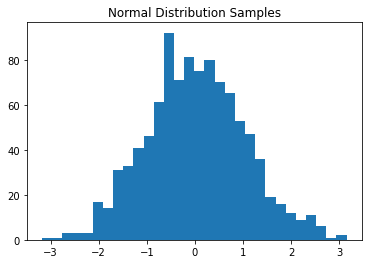

In [5]:
# Generate 1000 samples from a standard normal distribution
x = np.random.normal(0,1,1000)

# Plot histogram
plt.hist(x, bins=30)
plt.title("Normal Distribution Samples")
plt.show()


### Tasks
1. Estimate the **mean and variance** of the sample.
2. Repeat the experiment **100 times** and store the sample means.
3. Plot the distribution of the sample means.
4. Explain how this relates to the **Law of Large Numbers**.

## Exercise 2 

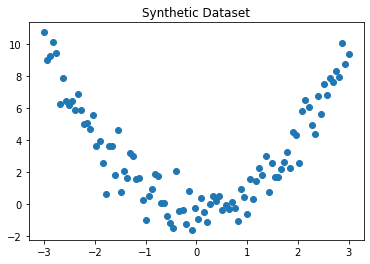

In [6]:
# Generate synthetic data
np.random.seed(0)
X = np.linspace(-3,3,100)
y = X**2 + np.random.normal(0,1,100)

plt.scatter(X,y)
plt.title("Synthetic Dataset")
plt.show()


### Tasks
1. Fit a **linear regression model**.
2. Fit a **polynomial regression model (degree 3)**.
3. Plot both predictions.
4. Which model better captures the data structure?

## Exercise 3 

In [7]:
# True function
def f(x):
    return np.sin(x)

# Generate training data
X = np.linspace(-3,3,30)
y = f(X) + np.random.normal(0,0.3,30)


### Tasks
1. Fit polynomial models with degrees **1, 3, 10**.
2. Plot predictions for each model.
3. Identify:
   - Underfitting
   - Overfitting
4. Repeat the experiment with **multiple datasets** and observe variability.

## Exercise 4 

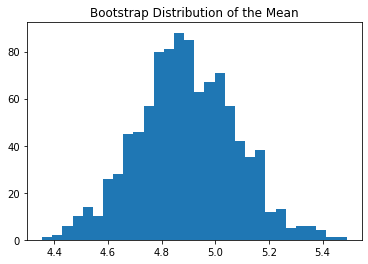

In [8]:
data = np.random.normal(5,2,100)

bootstrap_means = []

for i in range(1000):
    sample = np.random.choice(data, size=len(data), replace=True)
    bootstrap_means.append(np.mean(sample))

plt.hist(bootstrap_means, bins=30)
plt.title("Bootstrap Distribution of the Mean")
plt.show()


### Tasks
1. Compute the **bootstrap estimate of the standard error**.
2. Build a **95% confidence interval** using percentiles.
3. Compare the bootstrap estimate to the analytical standard error.

## Exercise 5 

In [9]:
# Generate dataset
X = np.linspace(-3,3,100).reshape(-1,1)
y = X[:,0]**2 + np.random.normal(0,1,100)


### Tasks
1. Split the dataset into **train/test sets**.
2. Fit polynomial models with degrees **1–10**.
3. Implement **5‑fold cross‑validation**.
4. Plot **degree vs cross‑validation error**.
5. Select the best model.

## Exercise 6 

In [10]:
models = []
predictions = []

for i in range(20):
    idx = np.random.choice(len(X), len(X), replace=True)
    X_sample = X[idx]
    y_sample = y[idx]
    
    model = DecisionTreeRegressor()
    model.fit(X_sample, y_sample)
    
    pred = model.predict(X)
    predictions.append(pred)

bagged_prediction = np.mean(predictions, axis=0)


### Tasks
1. Plot the bagged prediction vs a single decision tree.
2. Explain why bagging reduces **variance**.

## Exercise 7 

We will compare polynomial models using **AIC and BIC**.

Recall:

AIC = 2k − 2 log(L)  
BIC = k log(n) − 2 log(L)


In [ ]:
# Fit polynomial models and compute residual sum of squares
degrees = range(1,8)
rss = []

for d in degrees:
    model = make_pipeline(PolynomialFeatures(d), LinearRegression())
    model.fit(X,y)
    pred = model.predict(X)
    rss.append(np.sum((y - pred)**2))


### Tasks
1. Compute **AIC and BIC** from RSS.
2. Plot model degree vs AIC and BIC.
3. Compare the selected model with the **cross‑validation result**.

## Exercise 8 
Design your own experiment:

1. Generate a dataset with a **nonlinear function**.
2. Compare **three model selection methods**:
   - Cross‑validation
   - AIC
   - BIC
3. Which method selects the best model and why?
